In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [2]:
plt.style.use("seaborn-v0_8")
sns.set(font_scale=1.0)

In [3]:
df = pd.read_csv("/content/menstrual_absenteeism_50_countries.csv")

In [4]:
df.head()
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 14 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Country                                          53 non-null     object 
 1   Region                                           53 non-null     object 
 2   Income_Group                                     53 non-null     object 
 3   Girls_MHM_Education_Program_Coverage_%           53 non-null     int64  
 4   Schools_with_gender_separate_lockable_toilets_%  53 non-null     int64  
 5   Schools_with_bins_for_menstrual_waste_%          53 non-null     int64  
 6   Schools_providing_menstrual_products_%           53 non-null     int64  
 7   Girls_missing_school_during_menses_%             53 non-null     int64  
 8   Average_days_missed_per_cycle                    53 non-null     float64
 9   Reported_period_product_unaffordab

,Country,Region,Income_Group,Girls_MHM_Education_Program_Coverage_%,Schools_with_gender_separate_lockable_toilets_%,Schools_with_bins_for_menstrual_waste_%,Schools_providing_menstrual_products_%,Girls_missing_school_during_menses_%,Average_days_missed_per_cycle,Reported_period_product_unaffordability_%,Girls_aware_before_menarche_%,Female_lower_secondary_completion_%,Female_labor_force_participation_%,Estimated_future_earnings_loss_%
count,53,53,53,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000,53.000000
unique,53,7,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Ethiopia,Sub-Saharan Africa,High,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,11,17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,63.660377,62.415094,46.226415,25.000000,27.415094,1.609434,43.000000,68.528302,76.849057,45.377358,4.056604
std,NaN,NaN,NaN,21.155962,27.062914,30.571254,12.712804,11.989473,0.427544,18.781128,19.171898,25.615798,12.545650,2.776378
min,NaN,NaN,NaN,28.000000,22.000000,9.000000,7.000000,12.000000,1.000000,15.000000,33.000000,20.000000,8.000000,1.000000
25%,NaN,NaN,NaN,48.000000,40.000000,21.000000,14.000000,19.000000,1.300000,23.000000,54.000000,65.000000,36.000000,2.000000
50%,NaN,NaN,NaN,66.000000,61.000000,38.000000,25.000000,24.000000,1.500000,42.000000,72.000000,87.000000,49.000000,3.000000
75%,NaN,NaN,NaN,85.000000,95.000000,85.000000,38.000000,32.000000,1.800000,60.000000,85.000000,98.000000,54.000000,6.000000


In [5]:
df.duplicated().sum(), df["Country"].duplicated().sum()

(np.int64(0), np.int64(0))

In [6]:
# Ensure numeric columns are numeric
num_cols = [
    "Girls_MHM_Education_Program_Coverage_%",
    "Schools_with_gender_separate_lockable_toilets_%",
    "Schools_with_bins_for_menstrual_waste_%",
    "Schools_providing_menstrual_products_%",
    "Girls_missing_school_during_menses_%",
    "Average_days_missed_per_cycle",
    "Reported_period_product_unaffordability_%",
    "Girls_aware_before_menarche_%",
    "Female_lower_secondary_completion_%",
    "Female_labor_force_participation_%",
    "Estimated_future_earnings_loss_%"
]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

# Missing values
df.isna().sum()

,0
Country,0
Region,0
Income_Group,0
Girls_MHM_Education_Program_Coverage_%,0
Schools_with_gender_separate_lockable_toilets_%,0
Schools_with_bins_for_menstrual_waste_%,0
Schools_providing_menstrual_products_%,0
Girls_missing_school_during_menses_%,0
Average_days_missed_per_cycle,0
Reported_period_product_unaffordability_%,0


In [7]:
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())

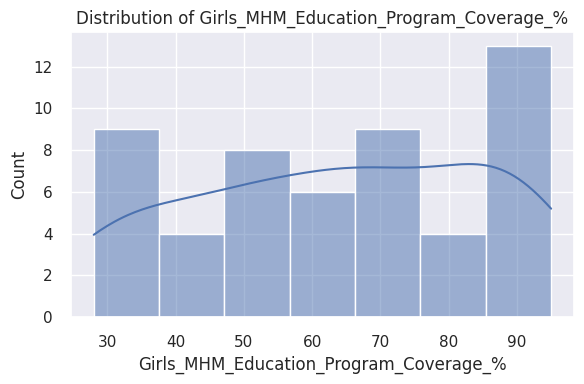

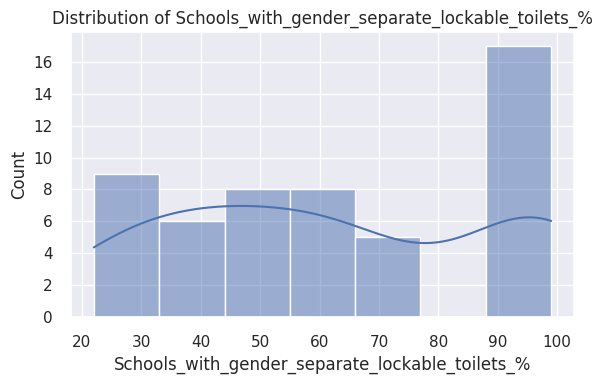

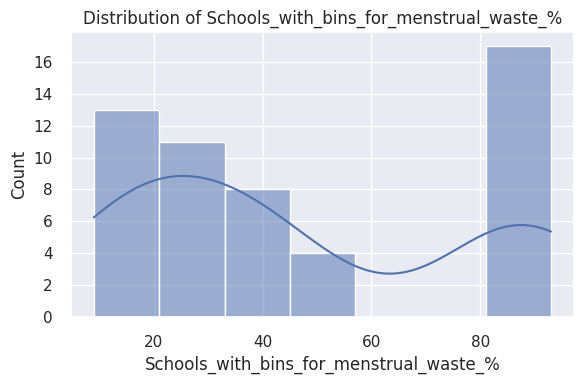

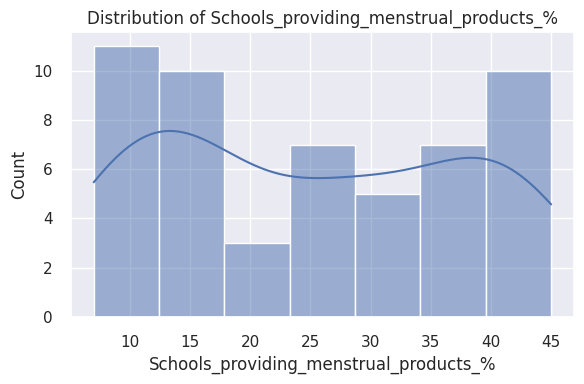

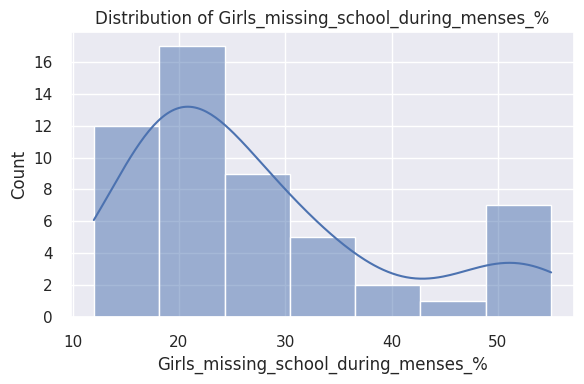

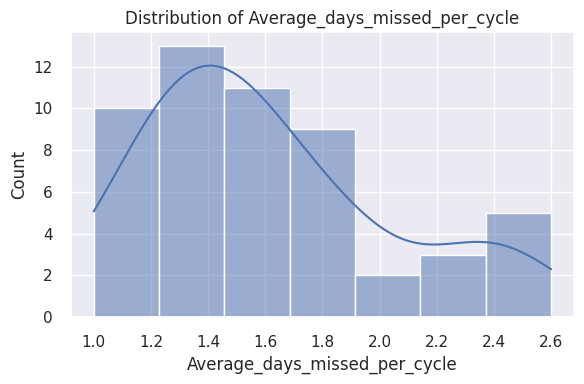

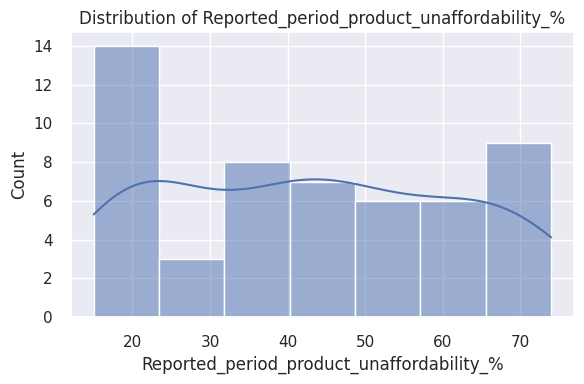

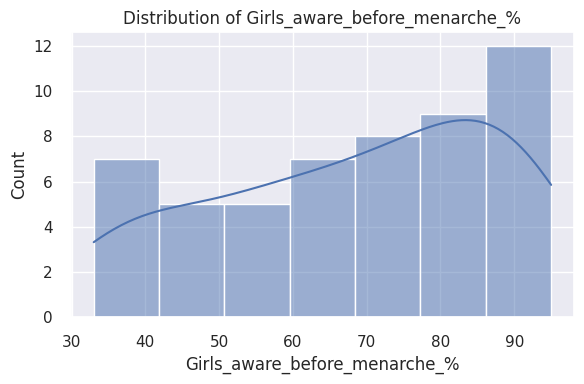

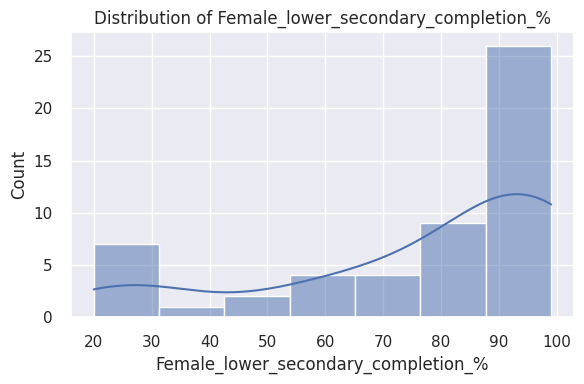

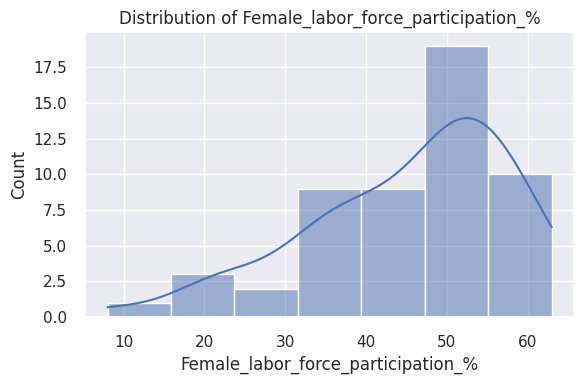

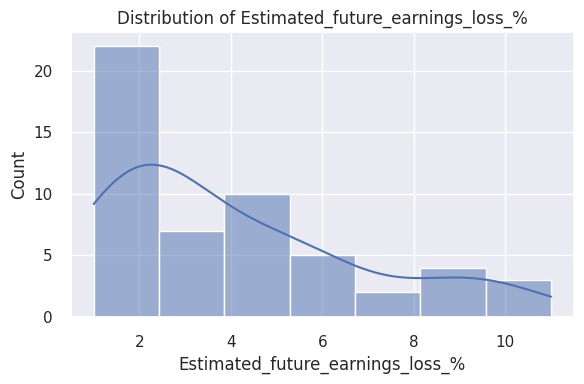

In [8]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

In [9]:
grouped_income = df.groupby("Income_Group")[num_cols].agg(["mean", "std", "min", "max"])
grouped_income

Girls_MHM_Education_Program_Coverage_%                    \
                                               mean       std min max   
Income_Group                                                            
High                                      88.117647  4.151541  80  95   
Low                                       31.333333  2.345208  28  35   
Lower-middle                              51.066667  6.261751  40  62   
Upper-middle                              69.000000  3.162278  64  74   

             Schools_with_gender_separate_lockable_toilets_%                \
                                                        mean       std min   
Income_Group                                                                 
High                                               96.470588  1.907801  92   
Low                                                25.111111  2.368778  22   
Lower-middle                                       44.133333  5.841559  35   
Upper-middle                                       65.000000  3.931227  60   

                 Schools_with_bins_for_menstrual_waste_%            ...  \
             max                                    mean       std  ...   
Income_Group                                                        ...   
High          99                               87.647059  3.141281  ...   
Low           30                               10.888889  1.833333  ...   
Lower-middle  55                               24.000000  4.000000  ...   
Upper-middle  71                               41.833333  3.613946  ...   

             Female_lower_secondary_completion_%      \
                                             min max   
Income_Group                                           
High                                          96  99   
Low                                           20  55   
Lower-middle                                  50  88   
Upper-middle                                  79  96   

             Female_labor_force_participation_%                     \
                                           mean        std min max   
Income_Group                                                         
High                                  54.235294   7.570745  34  63   
Low                                   30.888889  10.117367   8  40   
Lower-middle                          39.400000  11.287161  20  53   
Upper-middle                          51.166667   6.766674  34  61   

             Estimated_future_earnings_loss_%                    
                                         mean       std min max  
Income_Group                                                     
High                                 1.588235  0.507300   1   2  
Low                                  9.111111  1.166667   7  11  
Lower-middle                         5.000000  0.845154   4   6  
Upper-middle                         2.583333  0.514929   2   3  

[4 rows x 44 columns]

In [10]:
grouped_region = df.groupby("Region")[num_cols].mean().round(1)
grouped_region

,Girls_MHM_Education_Program_Coverage_%,Schools_with_gender_separate_lockable_toilets_%,Schools_with_bins_for_menstrual_waste_%,Schools_providing_menstrual_products_%,Girls_missing_school_during_menses_%,Average_days_missed_per_cycle,Reported_period_product_unaffordability_%,Girls_aware_before_menarche_%,Female_lower_secondary_completion_%,Female_labor_force_participation_%,Estimated_future_earnings_loss_%
Region,,,,,,,,,,,
East Asia & Pacific,74.0,74.7,57.5,30.0,21.0,1.4,34.0,79.3,92.6,53.7,2.5
Europe & Central Asia,82.8,86.3,74.5,36.2,18.4,1.3,26.0,86.0,96.5,53.5,1.9
Latin America & Caribbean,65.0,60.6,37.8,25.0,23.8,1.5,42.8,70.8,82.5,50.6,3.2
Middle East & North Africa,63.2,66.5,52.5,25.2,27.0,1.6,40.8,68.7,78.8,29.8,4.0
North America,89.0,95.5,84.0,44.5,17.5,1.2,19.5,85.5,98.5,59.5,2.0
South Asia,43.2,35.6,18.2,11.8,38.0,2.0,64.2,48.2,56.0,27.6,7.0
Sub-Saharan Africa,39.1,32.6,16.4,11.6,42.2,2.1,64.2,45.7,43.2,39.9,7.3


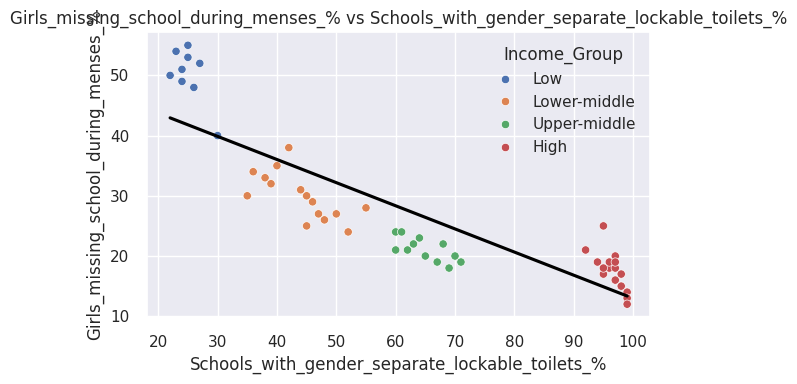

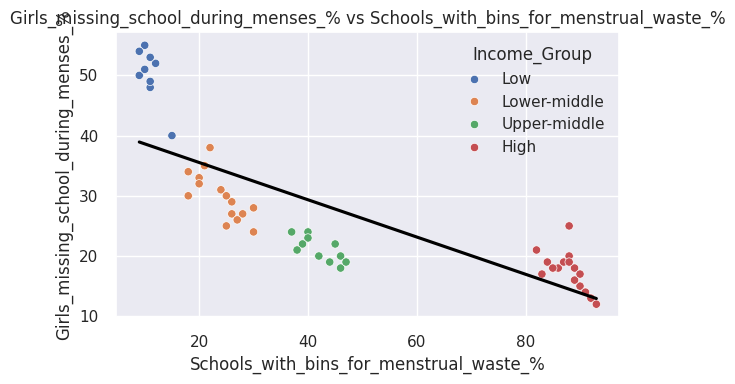

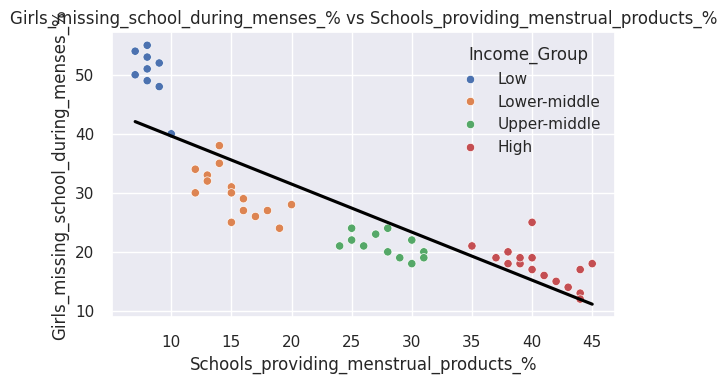

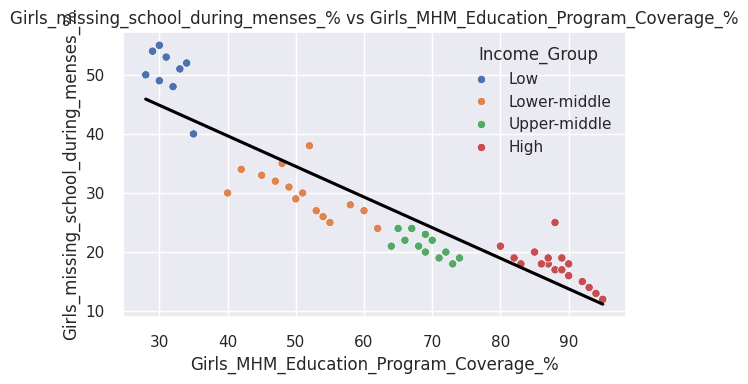

In [11]:
key_x = [
    "Schools_with_gender_separate_lockable_toilets_%",
    "Schools_with_bins_for_menstrual_waste_%",
    "Schools_providing_menstrual_products_%",
    "Girls_MHM_Education_Program_Coverage_%"
]

y = "Girls_missing_school_during_menses_%"

for col in key_x:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x=col, y=y, hue="Income_Group")
    sns.regplot(data=df, x=col, y=y, scatter=False, ci=None, color="black")
    plt.title(f"{y} vs {col}")
    plt.tight_layout()
    plt.show()

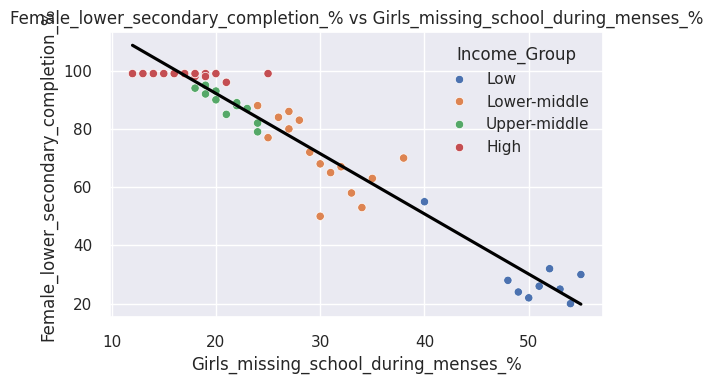

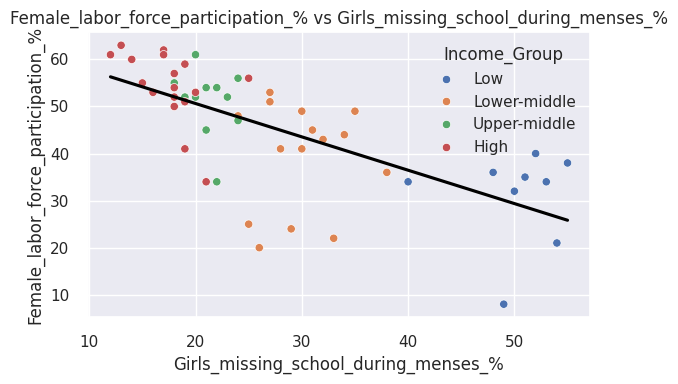

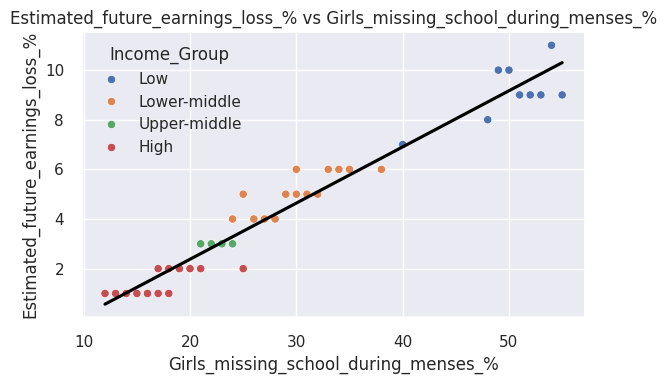

In [12]:
targets = [
    "Female_lower_secondary_completion_%",
    "Female_labor_force_participation_%",
    "Estimated_future_earnings_loss_%"
]

for t in targets:
    plt.figure(figsize=(6,4))
    sns.scatterplot(data=df, x="Girls_missing_school_during_menses_%", y=t, hue="Income_Group")
    sns.regplot(data=df, x="Girls_missing_school_during_menses_%", y=t, scatter=False, ci=None, color="black")
    plt.title(f"{t} vs Girls_missing_school_during_menses_%")
    plt.tight_layout()
    plt.show()

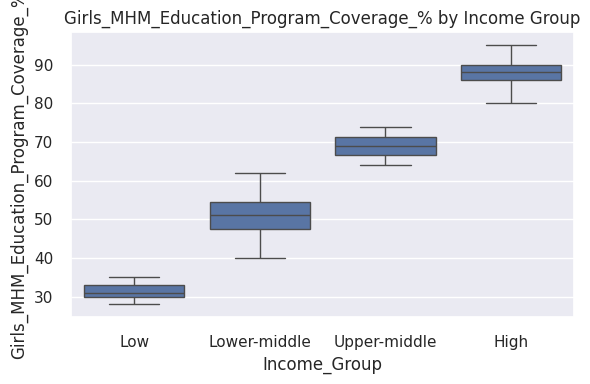

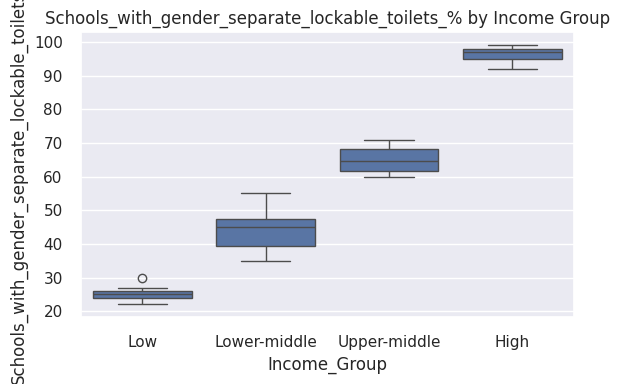

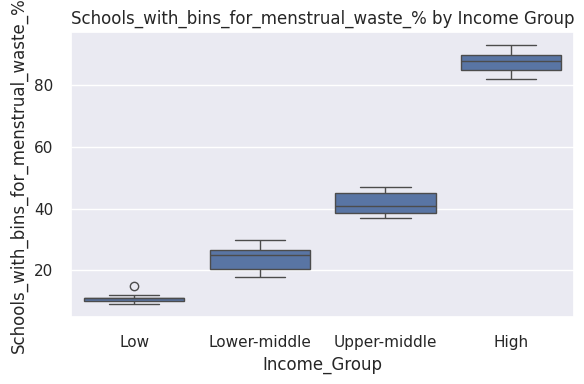

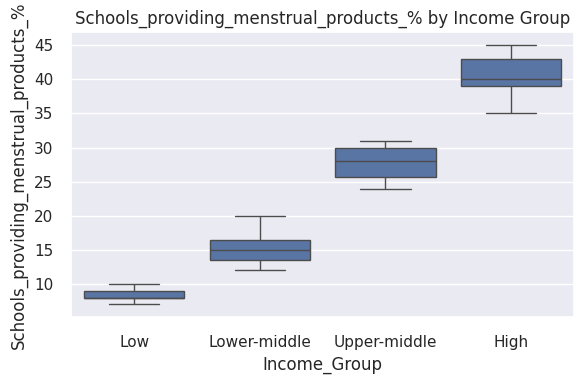

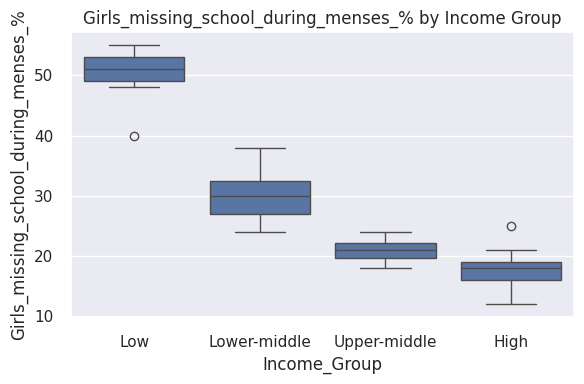

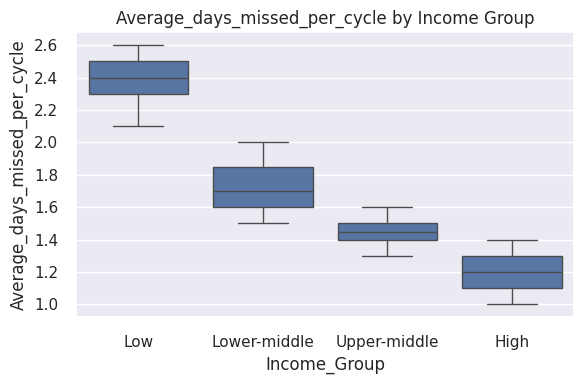

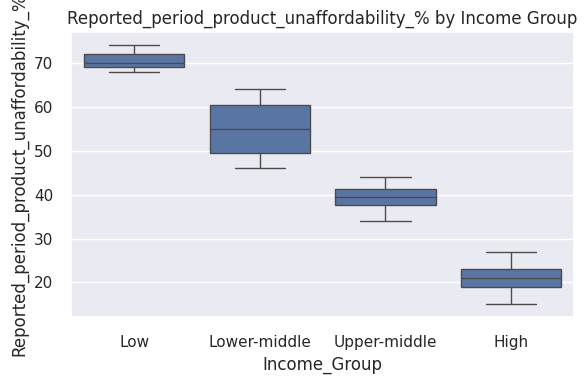

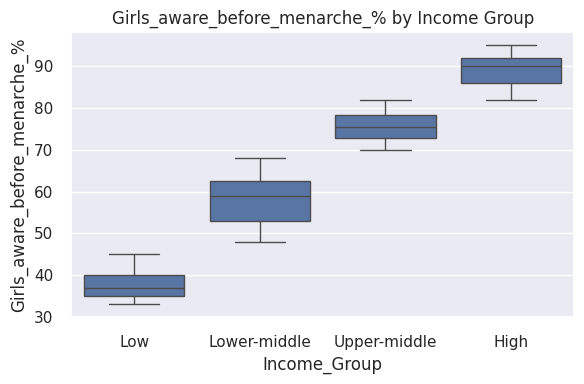

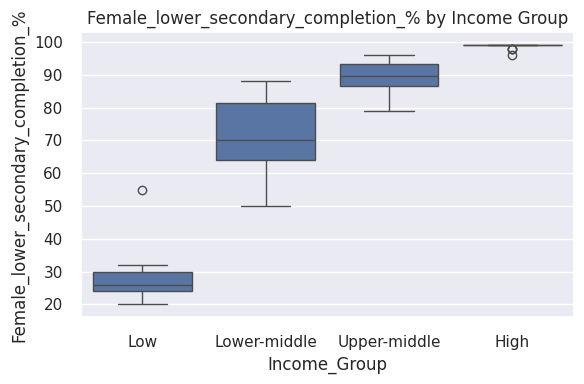

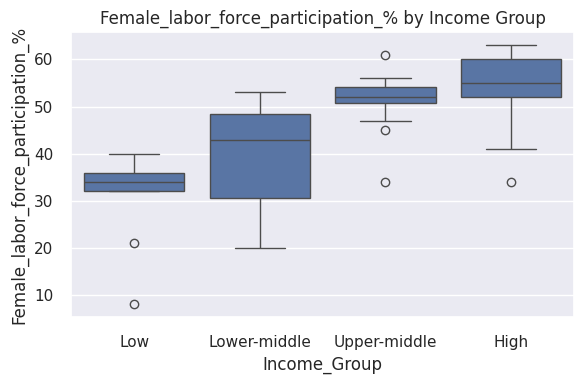

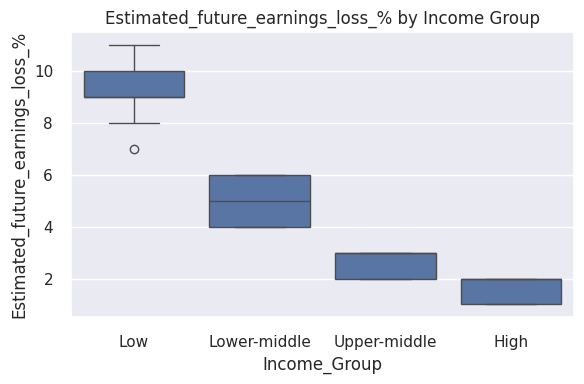

In [13]:
for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(data=df, x="Income_Group", y=col)
    plt.title(f"{col} by Income Group")
    plt.tight_layout()
    plt.show()

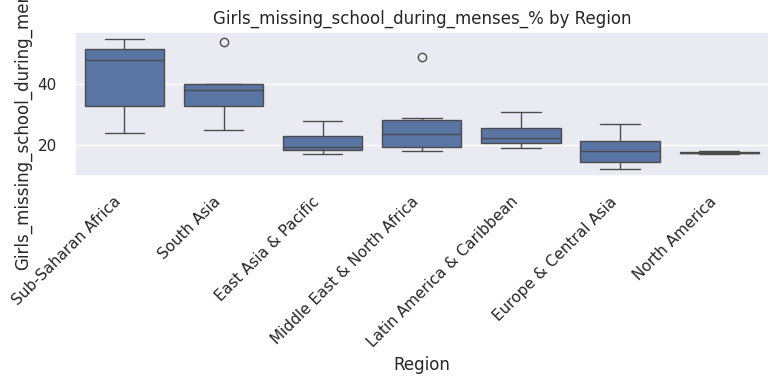

In [14]:
plt.figure(figsize=(8,4))
sns.boxplot(data=df, x="Region", y="Girls_missing_school_during_menses_%")
plt.xticks(rotation=45, ha="right")
plt.title("Girls_missing_school_during_menses_% by Region")
plt.tight_layout()
plt.show()

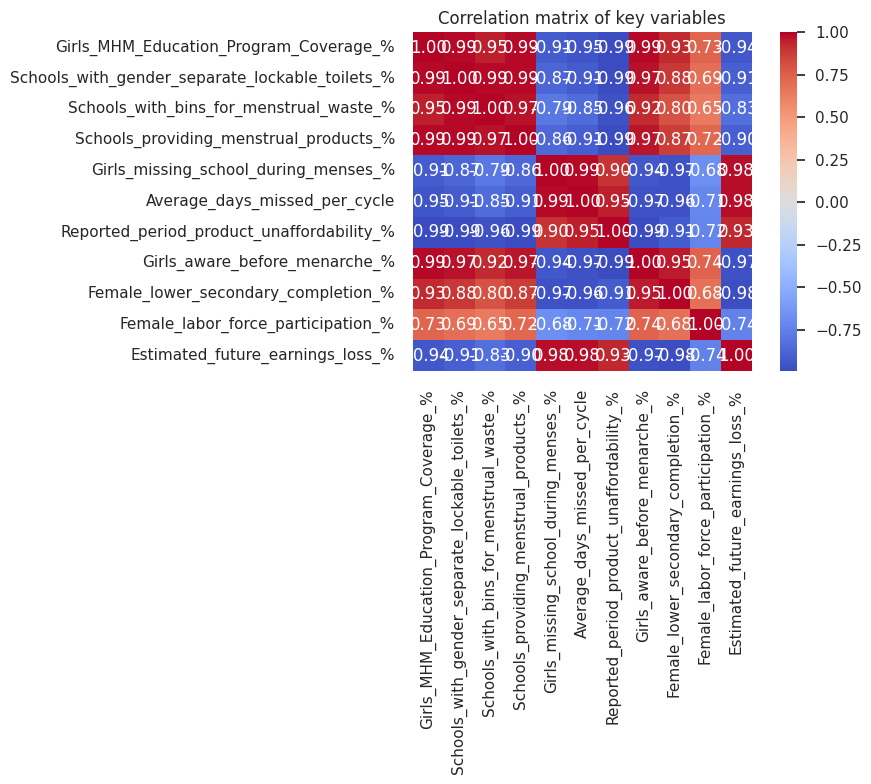

In [15]:
corr = df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation matrix of key variables")
plt.tight_layout()
plt.show()

In [16]:
corr_abs = corr["Girls_missing_school_during_menses_%"].sort_values(ascending=False)
corr_abs

,Girls_missing_school_during_menses_%
Girls_missing_school_during_menses_%,1.000000
Average_days_missed_per_cycle,0.985140
Estimated_future_earnings_loss_%,0.977362
Reported_period_product_unaffordability_%,0.904507
Female_labor_force_participation_%,-0.677136
Schools_with_bins_for_menstrual_waste_%,-0.788992
Schools_providing_menstrual_products_%,-0.863253
Schools_with_gender_separate_lockable_toilets_%,-0.867398
Girls_MHM_Education_Program_Coverage_%,-0.914160
Girls_aware_before_menarche_%,-0.939416


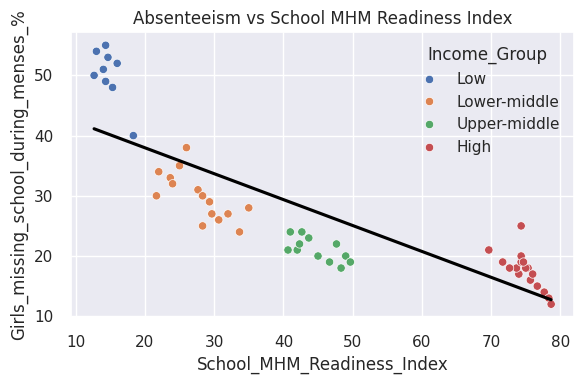

In [17]:
df["School_MHM_Readiness_Index"] = (
    df["Schools_with_gender_separate_lockable_toilets_%"] +
    df["Schools_with_bins_for_menstrual_waste_%"] +
    df["Schools_providing_menstrual_products_%"]
) / 3

plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x="School_MHM_Readiness_Index", y="Girls_missing_school_during_menses_%", hue="Income_Group")
sns.regplot(data=df, x="School_MHM_Readiness_Index", y="Girls_missing_school_during_menses_%", scatter=False, ci=None, color="black")
plt.title("Absenteeism vs School MHM Readiness Index")
plt.tight_layout()
plt.show()

In [18]:
import statsmodels.api as sm

X = df[[
    "School_MHM_Readiness_Index",
    "Girls_MHM_Education_Program_Coverage_%",
    "Reported_period_product_unaffordability_%",
]]
X = sm.add_constant(X)
y = df["Girls_missing_school_during_menses_%"]

model = sm.OLS(y, X).fit()
print(model.summary())

                                     OLS Regression Results                                     
Dep. Variable:     Girls_missing_school_during_menses_%   R-squared:                       0.924
Model:                                              OLS   Adj. R-squared:                  0.919
Method:                                   Least Squares   F-statistic:                     198.7
Date:                                  Sat, 27 Dec 2025   Prob (F-statistic):           2.04e-27
Time:                                          15:44:40   Log-Likelihood:                -138.04
No. Observations:                                    53   AIC:                             284.1
Df Residuals:                                        49   BIC:                             292.0
Df Model:                                             3                                         
Covariance Type:                              nonrobust                                         
                              